In [1]:

from pathlib import Path
from time import time

import lightning as pl
from lit_ecology_classifier.data.datamodule import DataModule
from lit_ecology_classifier.models.model import LitClassifier
from lightning.pytorch.loggers import CSVLogger

In [2]:
# path for the classifcation path
base_path = Path("..")
output_path = base_path / "output_test" 

output_path.mkdir(parents=True, exist_ok=True)
model_path = base_path / ".." / "models" / "zoo3.ckpt"
data_path = base_path / "data" /"mini_OOD"/"OOD1"

In [3]:

train_out = Path("..") / "train_out"
logger = CSVLogger(save_dir= train_out, name='csv_logs')

model = LitClassifier.load_from_checkpoint(model_path, strict=False)

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/EAWAG/ruizjuan

Using standard cross entropy loss


In [4]:
model.hparams.batch_size = 128
model.hparams.TTA = False
model.hparams.outpath = str(output_path)
model.hparams.datapath = str(data_path)
model.hparams.use_wandb = False
model.hparams.model_name = "zoo3"
model.hparams.only_test = True

In [5]:
print(model.hparams)

"TTA":              False
"balance_classes":  False
"batch_size":       128
"class_map":        {'aphanizomenon': 0, 'asplanchna': 1, 'asterionella': 2, 'bosmina': 3, 'ceratium': 4, 'chaoborus': 5, 'chlorophyte_colonial_reproduction': 6, 'chydorus': 7, 'collotheca': 8, 'conochilus': 9, 'copepod_skin': 10, 'cyclops': 11, 'daphnia': 12, 'daphnia_cucullata': 13, 'daphnia_skin': 14, 'diaphanosoma': 15, 'diatom_chain': 16, 'dinobryon': 17, 'eudiaptomus': 18, 'filament': 19, 'fish': 20, 'fragilaria': 21, 'hydra': 22, 'kellicottia': 23, 'keratella_cochlearis': 24, 'keratella_quadrata': 25, 'leptodora': 26, 'limnoraphis': 27, 'maybe_cyano': 28, 'nauplius': 29, 'paradileptus': 30, 'pennate_diatom': 31, 'polyarthra': 32, 'rotifer': 33, 'synchaeta': 34, 'trichocerca': 35, 'unknown': 36, 'uroglena': 37}
"datapath":         ../data/mini_OOD/OOD1
"dataset":          zoo3
"loss":             cross_entropy
"lr":               0.0001
"lr_factor":        0.01
"main_param_path":  ./params/
"max_epochs": 

In [6]:
data_module = DataModule(**model.hparams)
data_module.setup("test")
model.load_datamodule(data_module)

Train size:  0
Validation size:  0
Test size:  843


In [7]:
trainer = pl.Trainer(
        # Set the number of GPUs to use for prediction if no_gpu is not set
        devices=  1, 
        strategy= "auto",
        enable_progress_bar = True,
        default_root_dir=output_path,
        logger=logger,
    )
    

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Train size:  0
Validation size:  0
Test size:  843


Testing: |          | 0/? [00:00<?, ?it/s]

/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:121: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2642: UserWarning: labels size, 4, does not match size of target_names, 38
  wa

test_roc_auc_binary: 0.997624703087886
test_balanced_acc: 0.46144376642088314
test_false_positives: 1.0
test_acc: 0.8161328588374852
test_f1: 0.48052711177711177
test_auc_macro: 0.5757245633209114
test_precision: 0.687665343915344
test_recall: 0.46144376642088314
../output_test/zoo3_OOD1/classifications_zoo3_OOD1.csv
Classification artefacts saved to ../output_test/zoo3_OOD1


[{}]

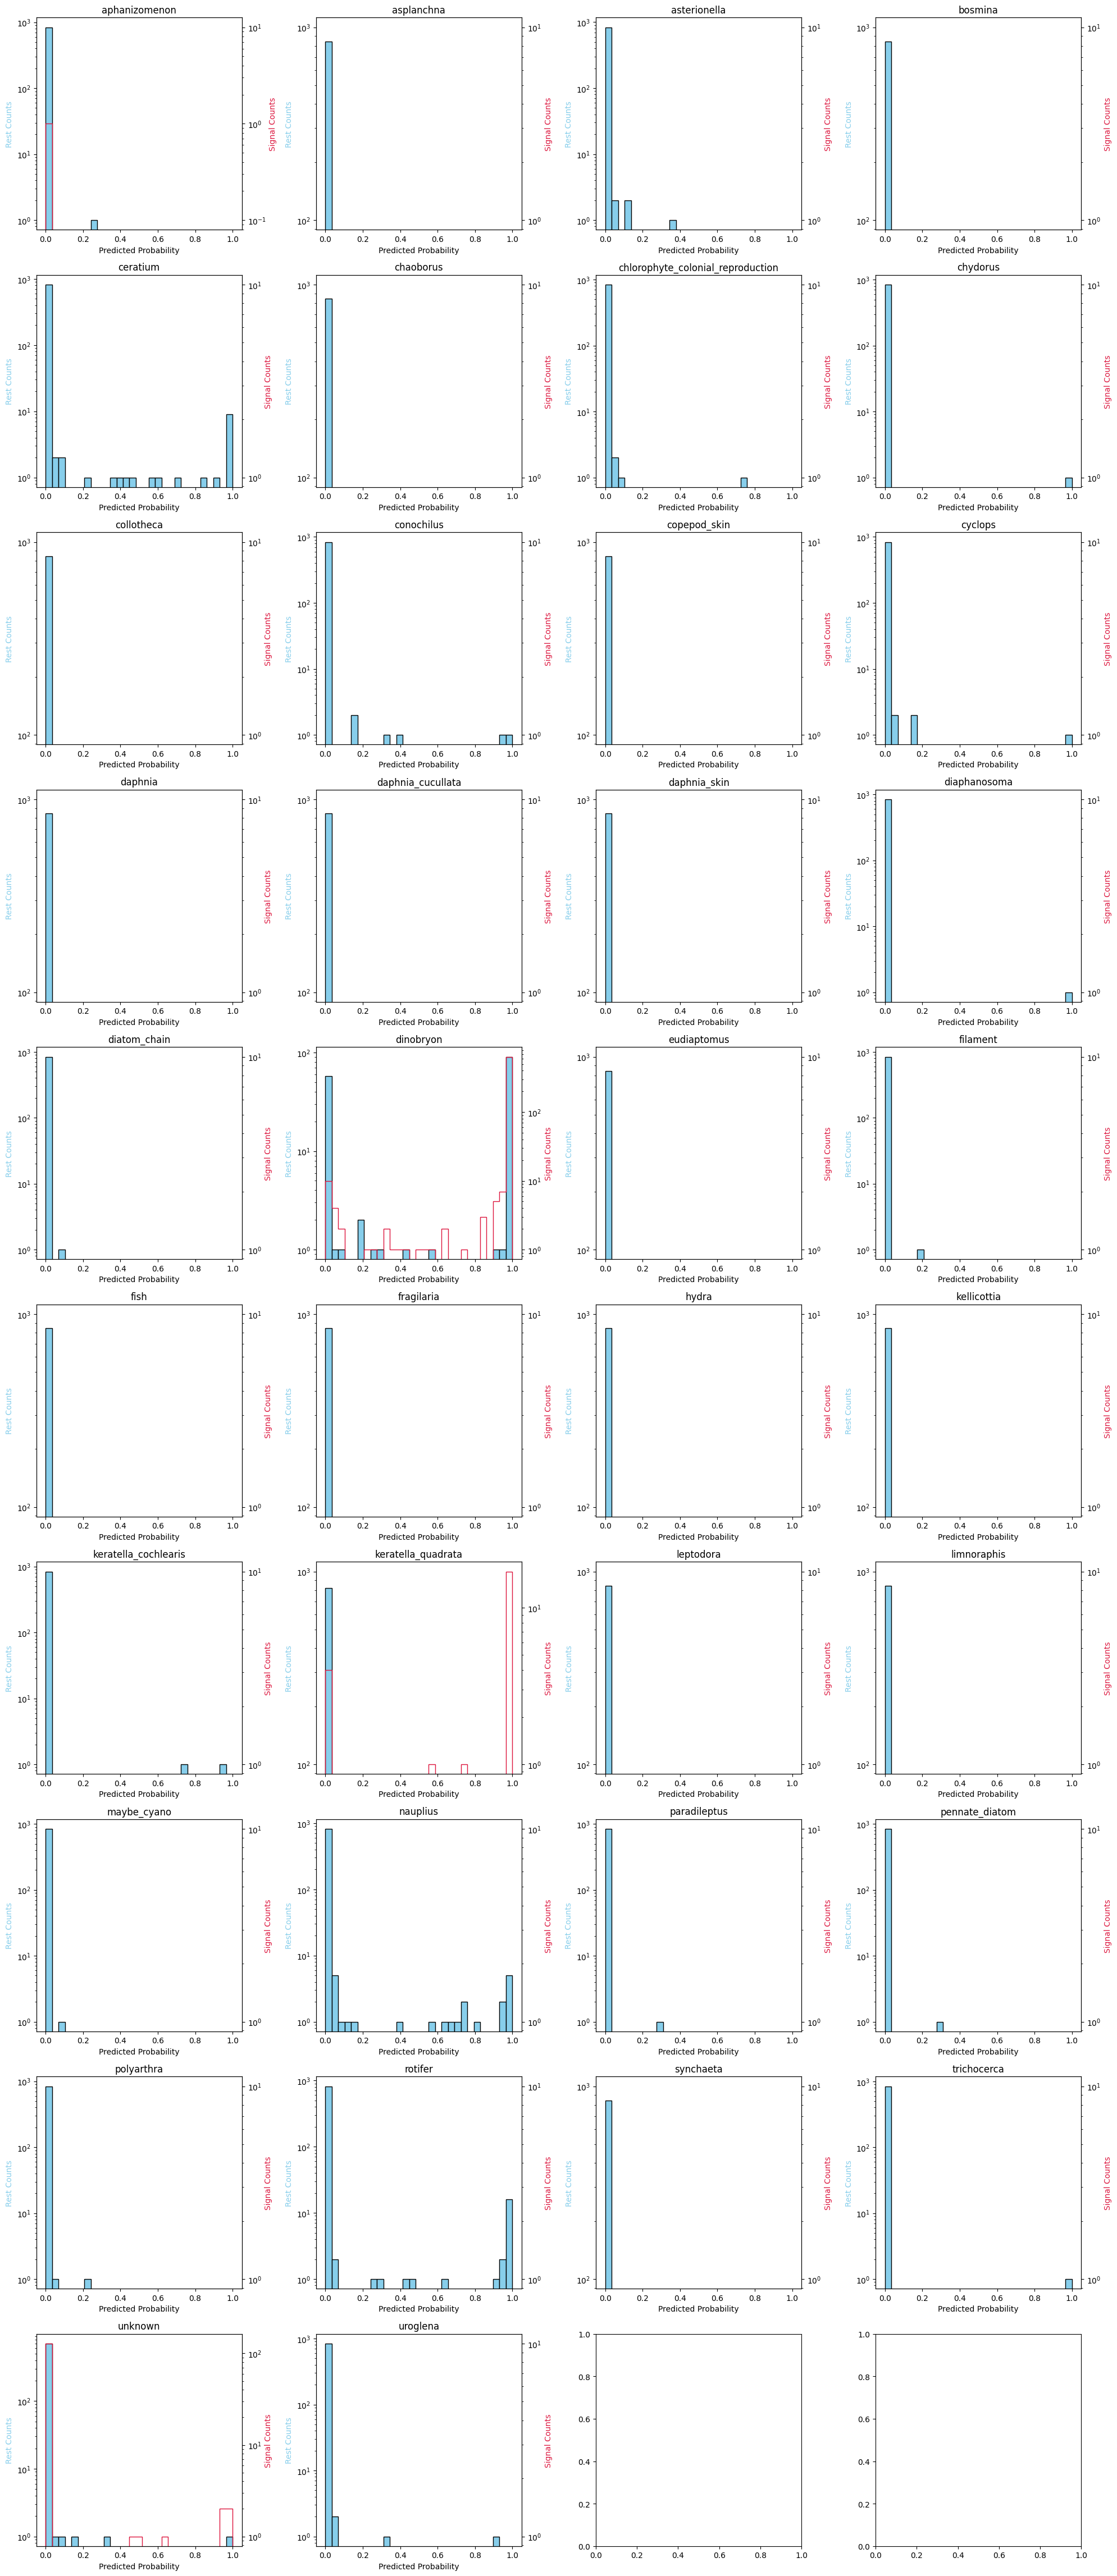

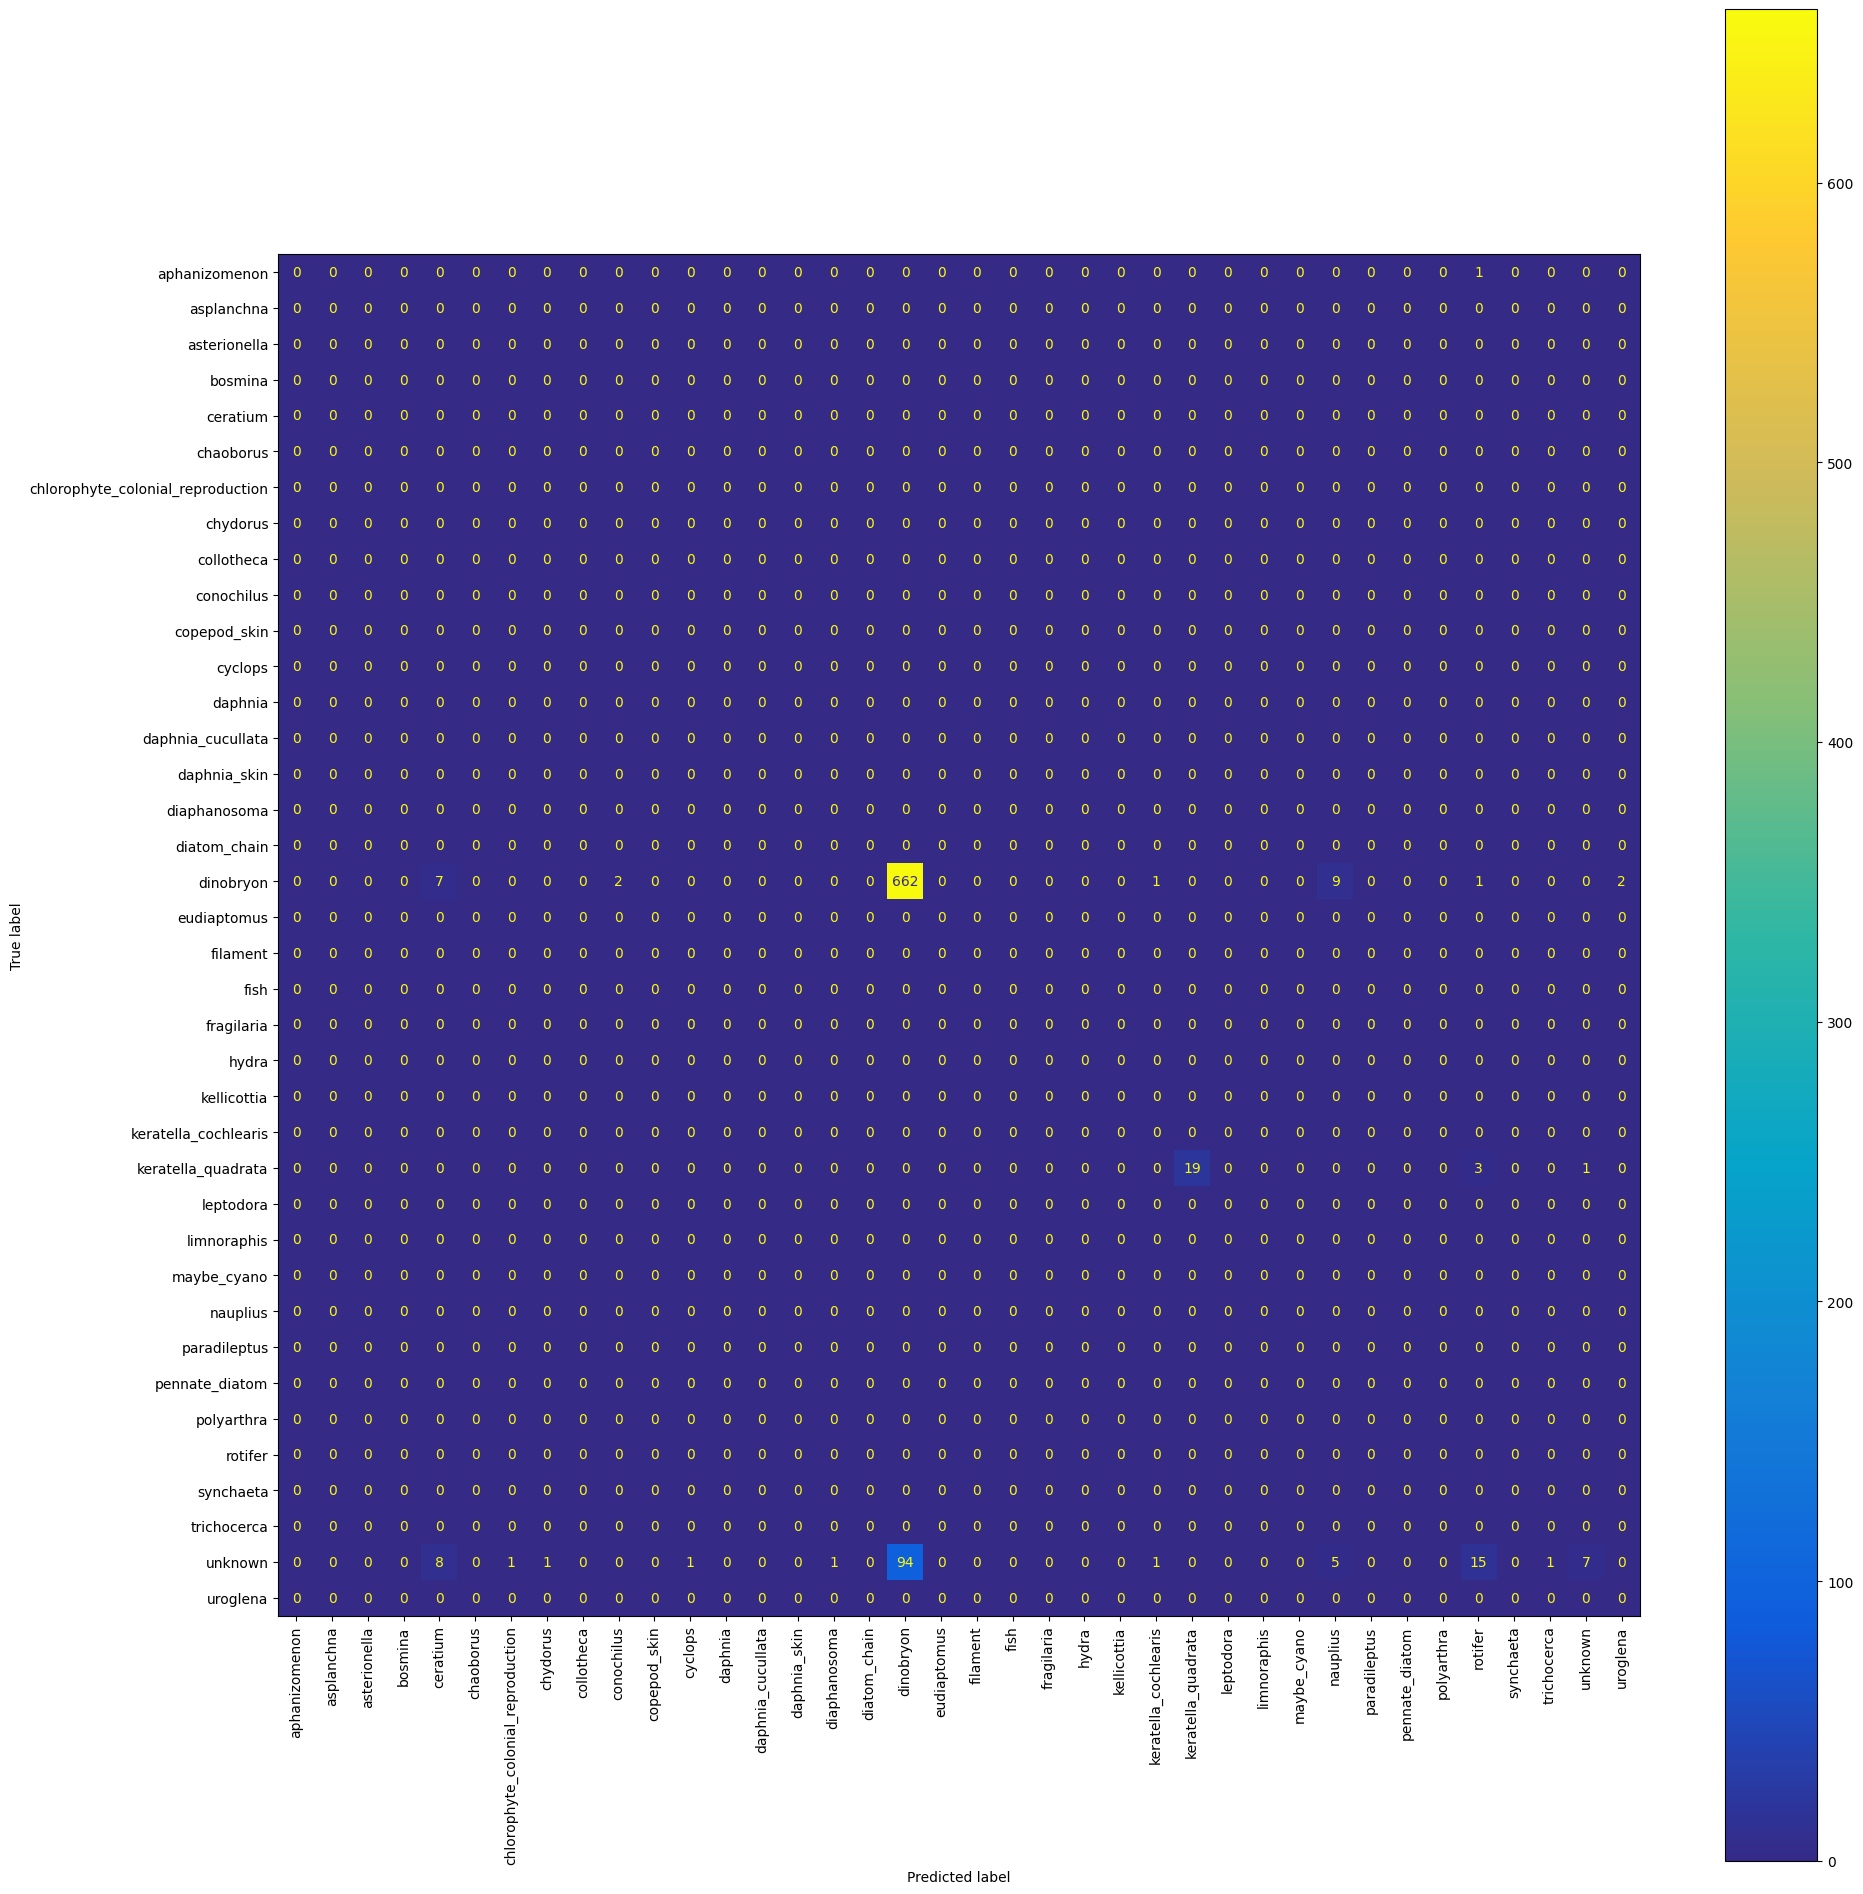

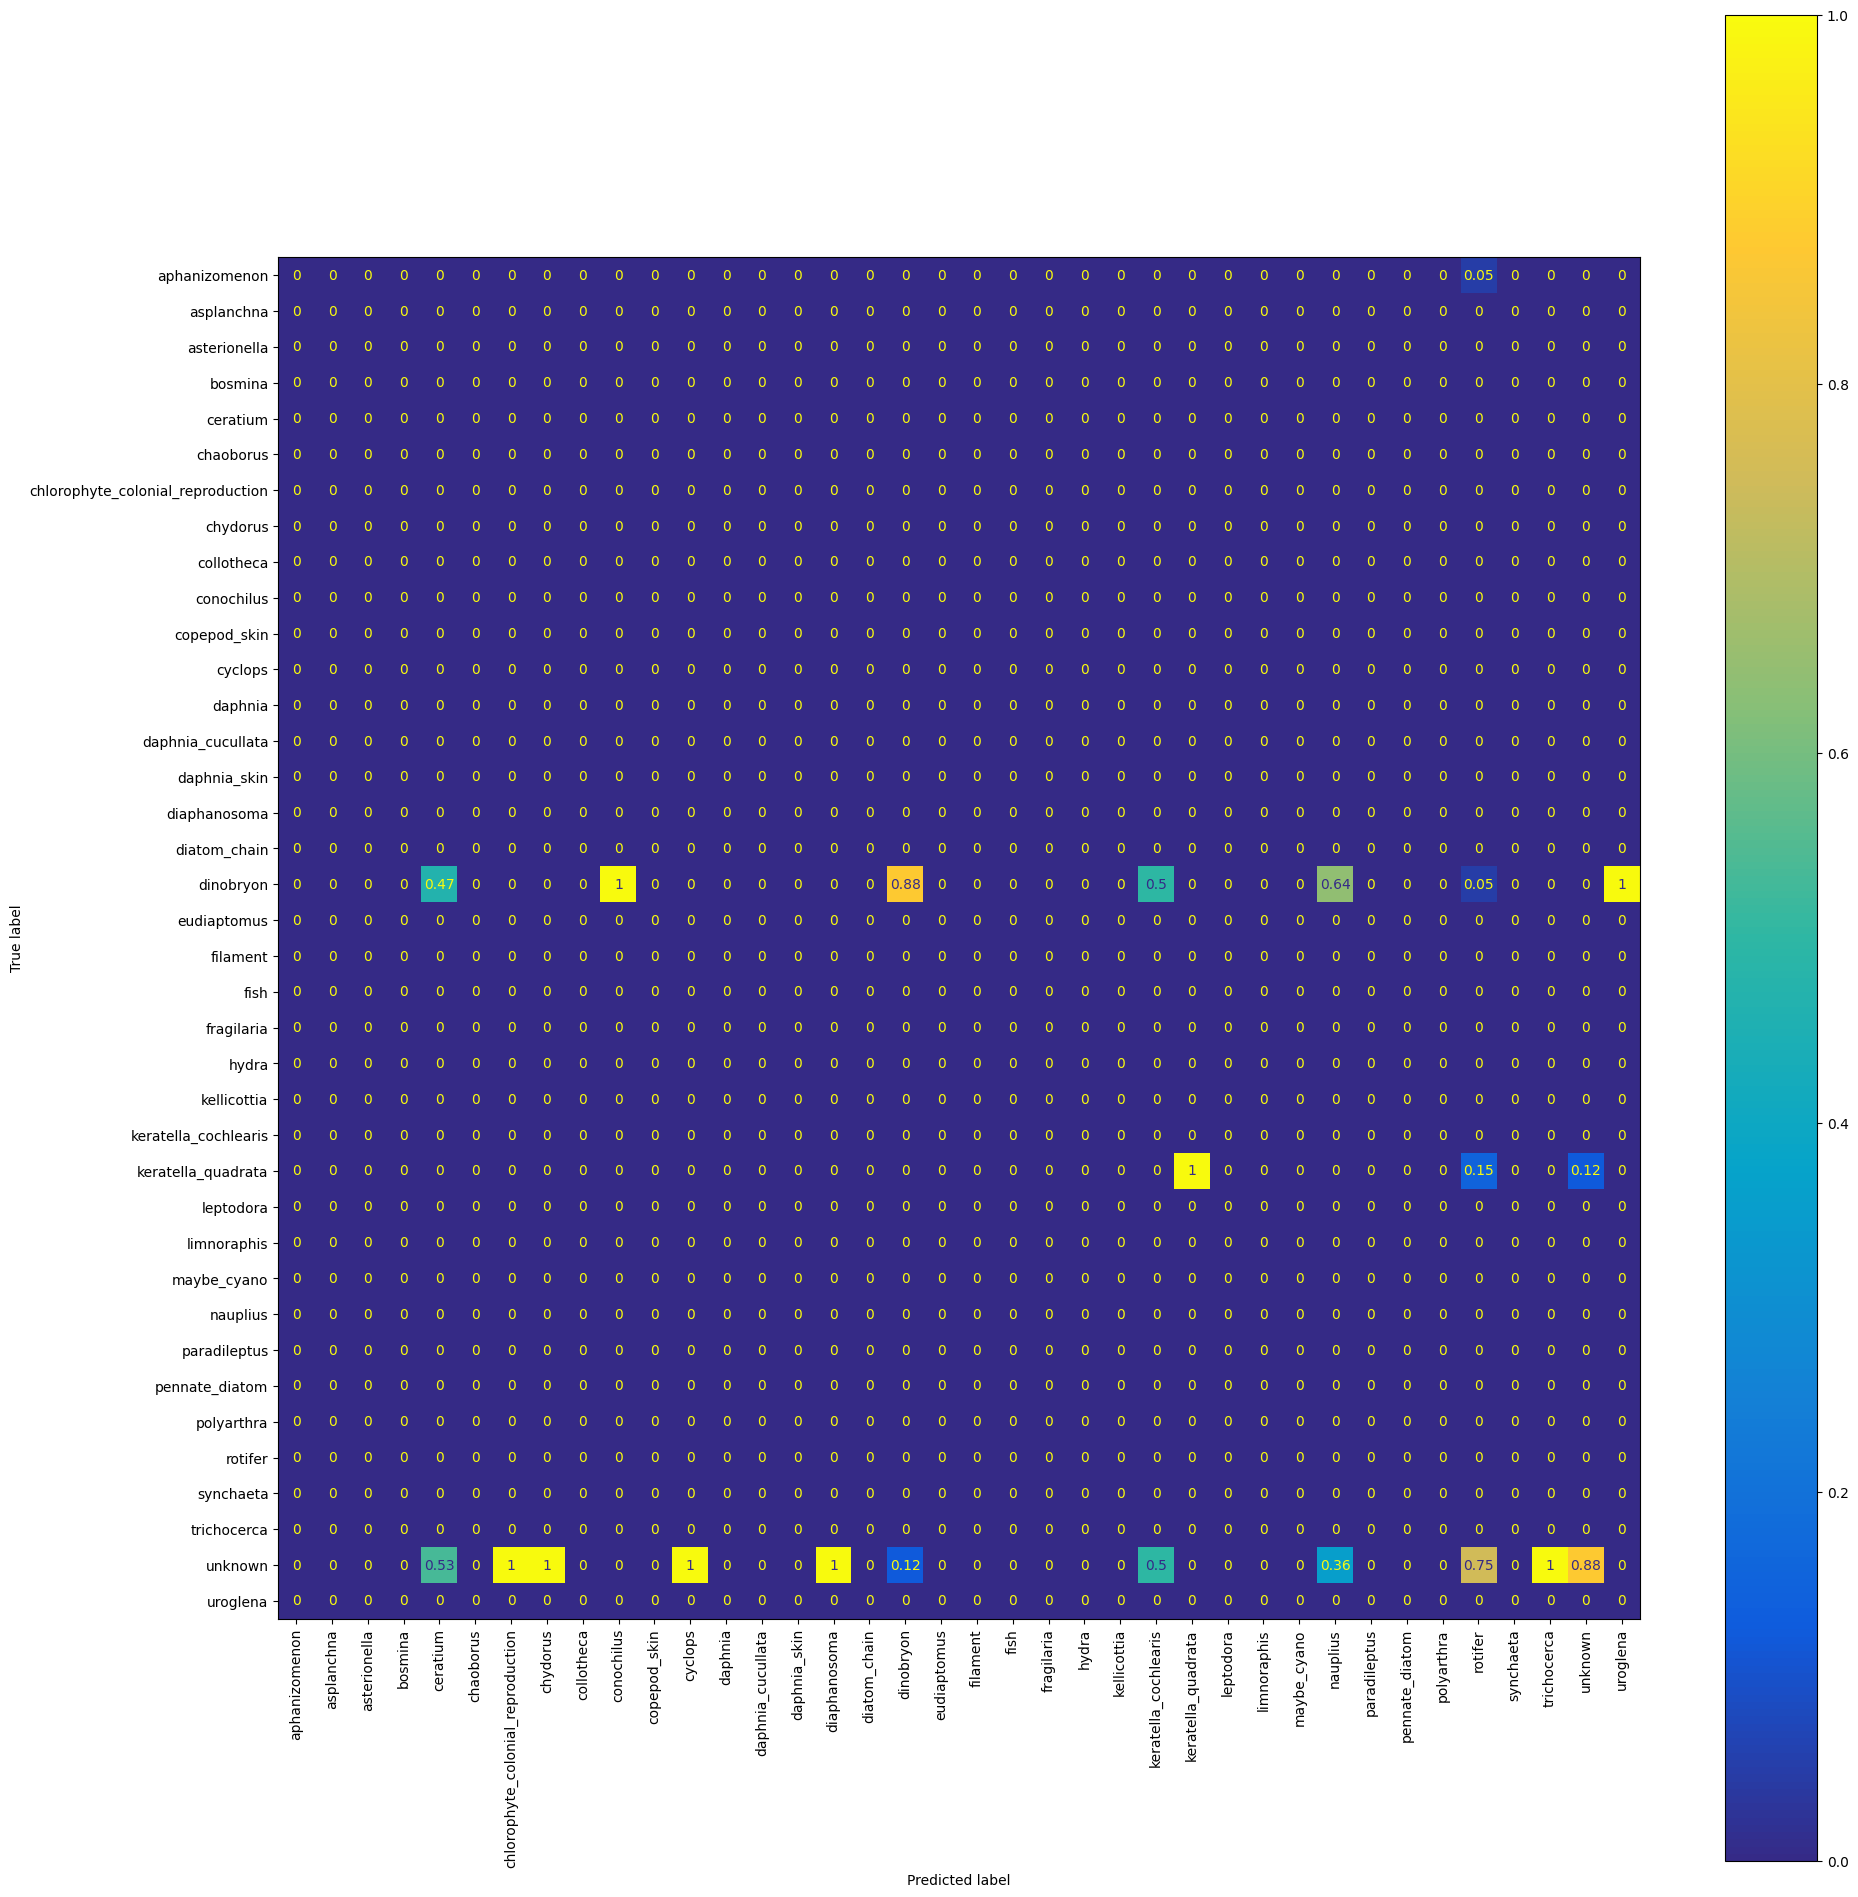

In [8]:
trainer.test(model, datamodule=data_module)

In [ ]:
test_acc = model.test_acc
test_f1 = model.test_f1
model_name = model.hparams.model_name
test_cells = model.test_cell 

print(f"Test accuracy for {model_name} is {test_acc:.2f}")
print(f"Test F1 for {model_name} is {test_f1:.2f}")


# Test multiple cells

In [3]:
#model
model_paths = [model_path]

#model containing the model to be tested
ood_dir = "..//data//mini_OOD"

# alterantive, you can give multiple 
test_cells = ["..//data//mini_OOD//OOD1", "..//data//mini_OOD//OOD2",]

output_path = "..//output_test"

/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
2025-03-07 15:22:50,936 - INFO - Preparing the model using a cached backbone or downloading from huggingface.
2025-03-07 15:22:51,765 - INFO - Model initialized with hyperparame

Model setup completed.
Model architecture:  beitv2
Number of classes:  38
Pretrained:  False
Total number of trainable parameters: %d 85791206
Total number of parameters: %d 85791206
Using standard cross entropy loss
Train size:  0
Validation size:  0
Test size:  463
Train size:  0
Validation size:  0
Test size:  463


Testing: |                                                                                                    …

/media/marco/dropbox-2Tb/Dropbox/LAVORO/PROJECTS/AQUASCOPE/PLANKTON-CLASSIFIER/lit_ecology_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:123: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 4, does not match size of target_names, 38
  warnings.warn(


test_roc_auc_binary: 1.0
test_balanced_acc: 0.5813700185835226
test_false_positives: 0.0
test_acc: 0.3650107991360691
test_f1: 0.49922581553295564
test_auc_macro: 0.5544610987886565
test_precision: 0.6939909297052154
test_recall: 0.5813700185835226
../output_test/2025-03-07_15-22-48/zoo3_OOD7/classifications_zoo3_OOD7.csv
Classification artefacts saved to ../output_test/2025-03-07_15-22-48/zoo3_OOD7


TypeError: cannot unpack non-iterable NoneType object

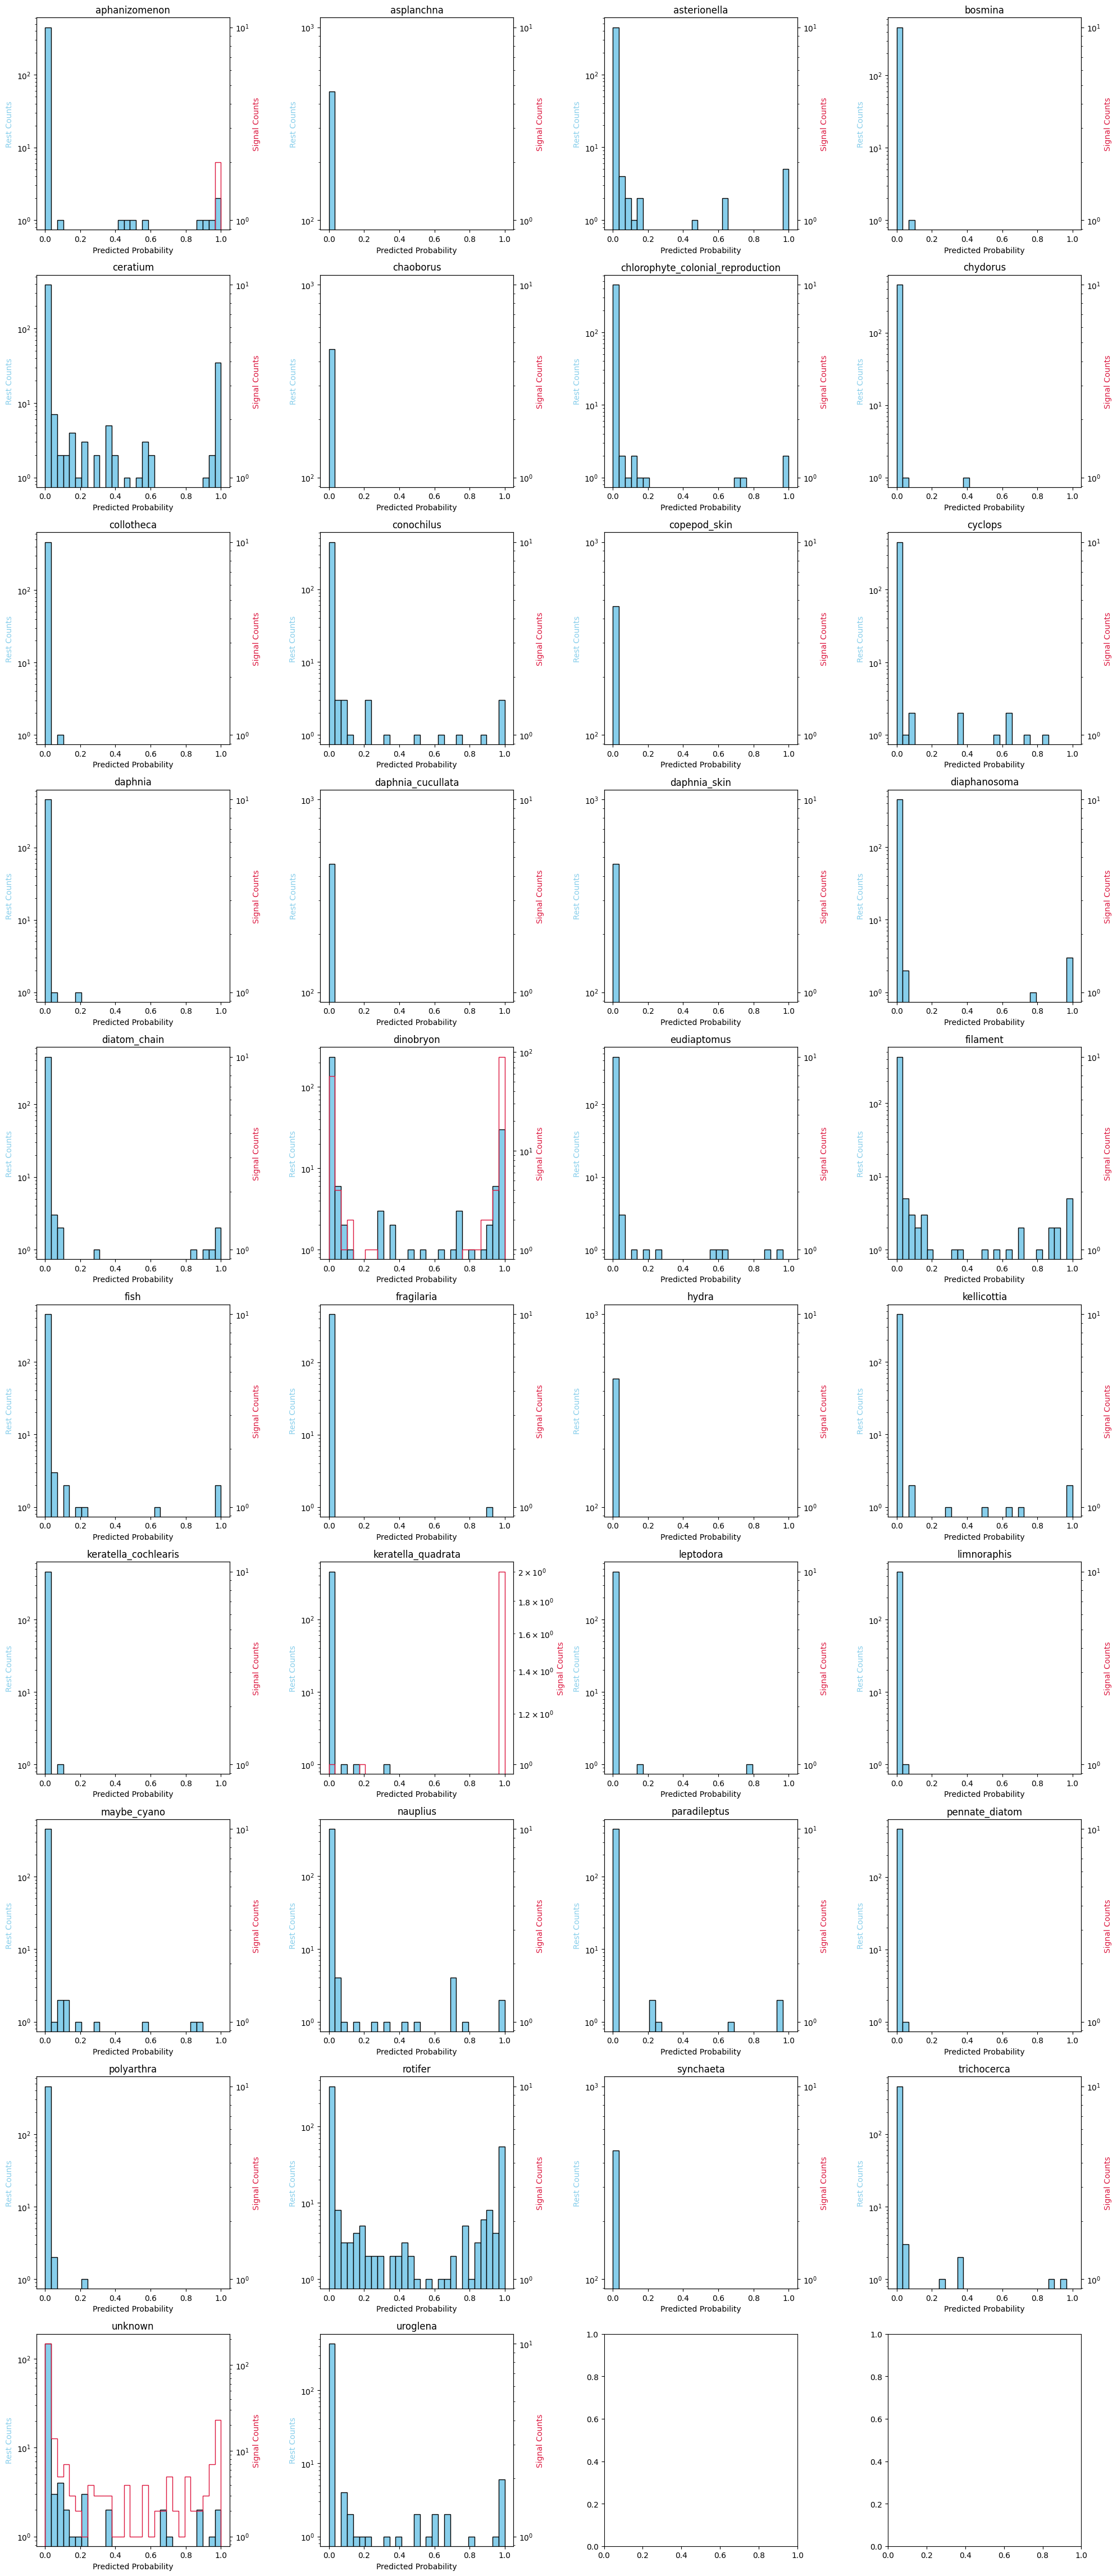

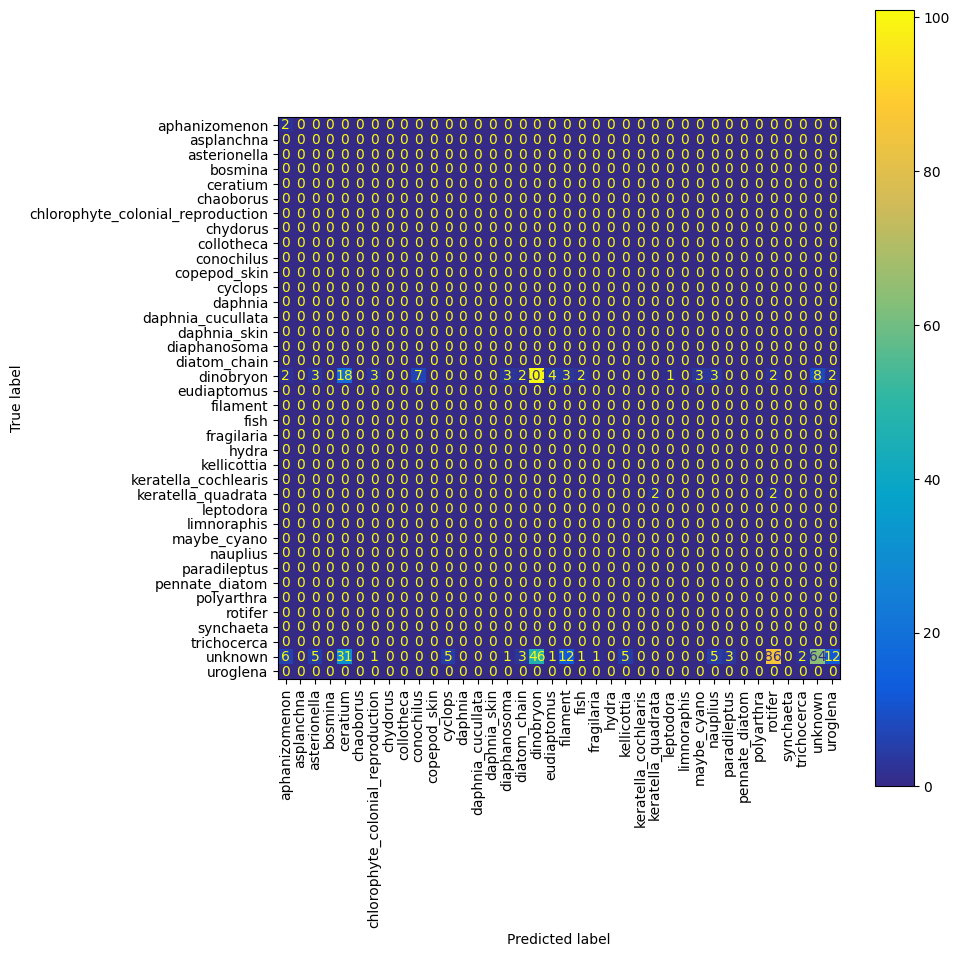

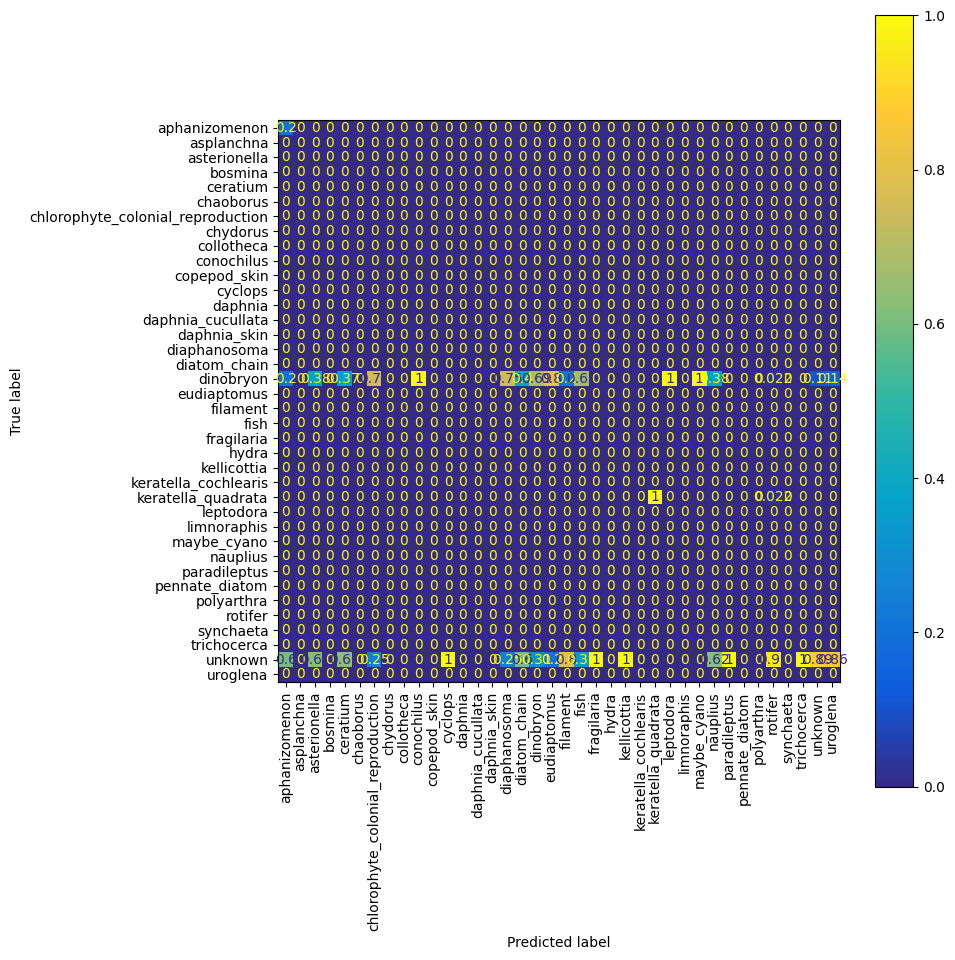

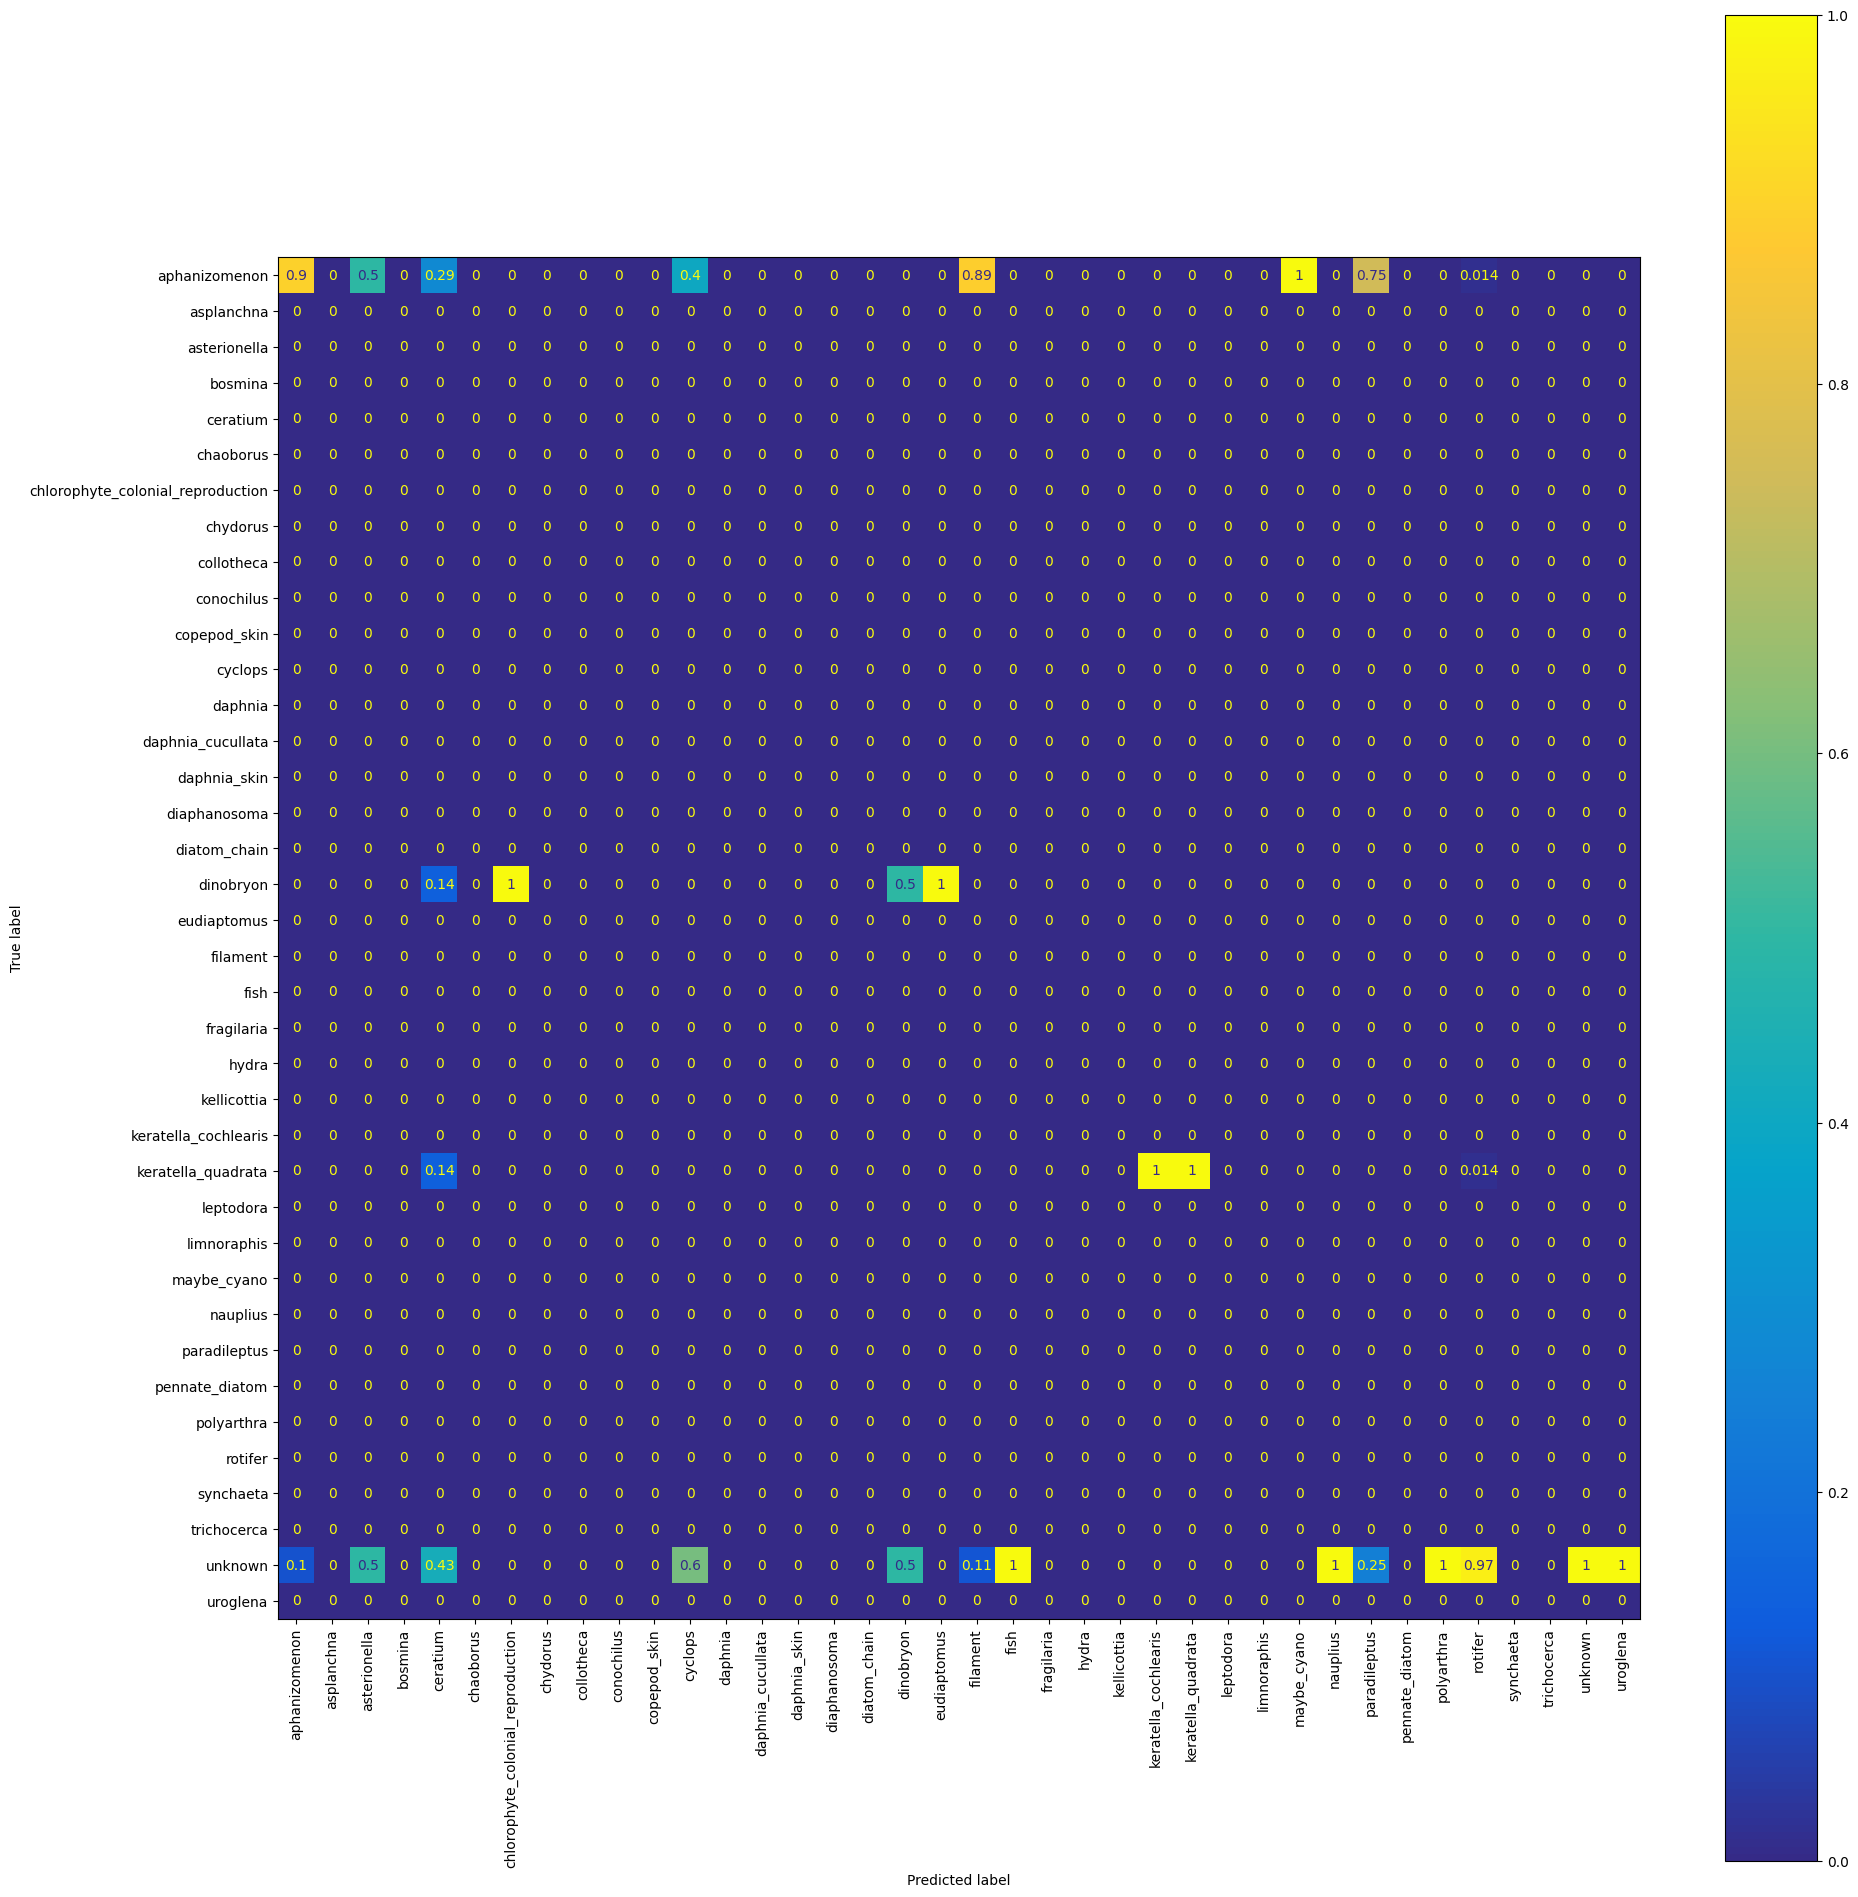

In [4]:
from lit_ecology_classifier.test_cells import Testing
import torch

cell_tester = Testing(model_paths, output_path, ood_dir=ood_dir, strict=False)

trainer = pl.Trainer(
        devices=1,
        strategy="auto",
        enable_progress_bar=True, default_root_dir=output_path
        )
    
cell_tester.trainer(trainer)
cell_tester.test()


In [7]:
performance_df = cell_tester.get_performance_overview()
performance_df.head()

,model,cell,accuracy,f1


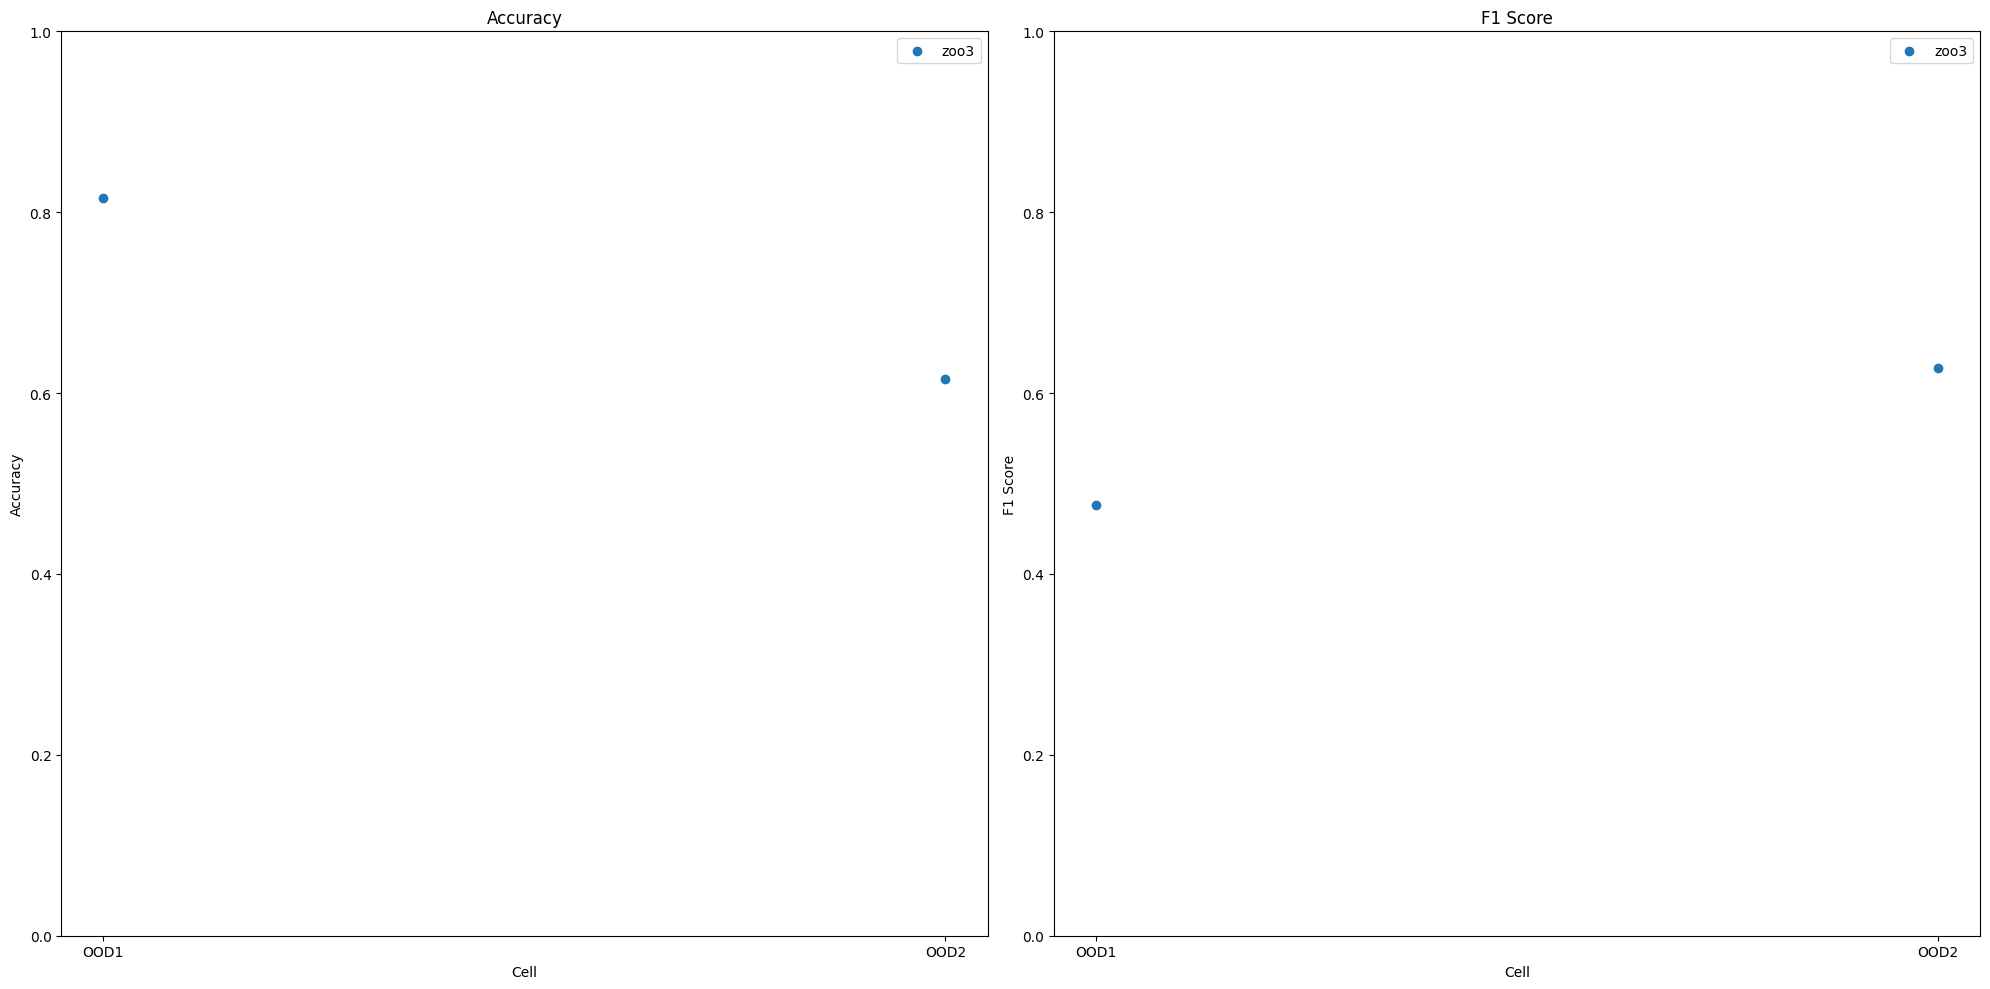

In [13]:
from lit_ecology_classifier.helpers.modelling_plots import plot_model_performance

plot_model_performance(performance_df)

